In [141]:
import numpy as np
import pandas as pd
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)

### helping functions/ methods

In [29]:
def get_dataset(dataset:str)->str:
    try:
        return pd.read_csv(os.path.join('..','data','raw',f'{dataset}.csv'))
    except Exception as e:
        warnings.warn(f'"{dataset}" dataset not present.')
        return None

In [30]:
def check_is_unique(dataframe,column_names):
    '''
    print that the given columns is unique or not.
    parameters:
    dataframe: pandas dataframe
    column_name : name of the column which want to check.
    '''
    if  type(column_names) == str:
        print(f"'{column_names}' is a unique in table ? { dataframe[column_names].is_unique}")
        return; 
    else:
        for column_name in column_names:
            print(f"'{column_name}' is a unique in table ? { dataframe[column_name].is_unique}")


### Load the datasets

In [31]:
# import the dataset
df_customers = get_dataset('customers')
df_order_items  = get_dataset('order_items')
df_geolocation = get_dataset('geolocation')
df_sellers = get_dataset('sellers')
df_orders = get_dataset('orders')
df_reviews = get_dataset('order_reviews')

#### understand the data

#### Geolocation table

In [32]:
df_geolocation.head(3)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.551427,-46.634074,sao paulo,SP
1,1001,-23.551337,-46.634027,sao paulo,SP
2,1001,-23.550642,-46.634410,sao paulo,SP


In [33]:
df_geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 720154 entries, 0 to 720153
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  720154 non-null  int64  
 1   geolocation_lat              720154 non-null  float64
 2   geolocation_lng              720154 non-null  float64
 3   geolocation_city             720154 non-null  str    
 4   geolocation_state            720154 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 27.5 MB


In [93]:
check_is_unique(df_geolocation,'geolocation_zip_code_prefix')

'geolocation_zip_code_prefix' is a unique in table ? False


In [94]:
df_geolocation.duplicated(subset=['geolocation_zip_code_prefix'],keep='first').sum()

np.int64(701139)

#### So there is catch that 'geolocation_zip_code_prefix' have the duplicate entries so in order to join it with customer and seller we first take median of latitude and longitude of each zip code

In [95]:
df_unique_geolocation = (df_geolocation.groupby('geolocation_zip_code_prefix')
                            .agg({'geolocation_lat':'median','geolocation_lng':'median'})
                            .reset_index())

In [96]:
check_is_unique(df_unique_geolocation,'geolocation_zip_code_prefix')

'geolocation_zip_code_prefix' is a unique in table ? True


In [97]:
df_unique_geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 445.8 KB


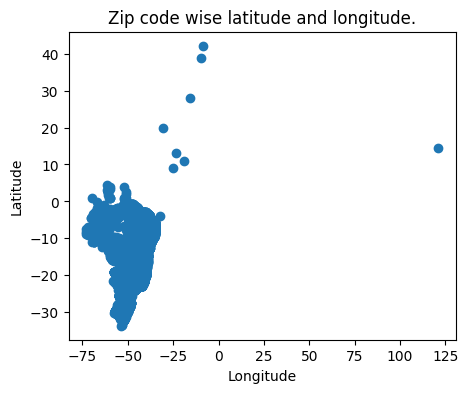

In [98]:
plt.figure(figsize=(5,4))
plt.scatter(y = df_unique_geolocation['geolocation_lat'],x=df_unique_geolocation['geolocation_lng'])
plt.title('Zip code wise latitude and longitude.')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show();

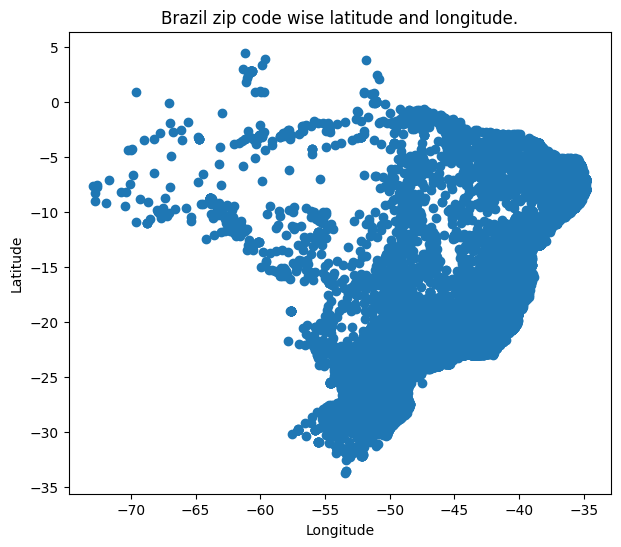

In [99]:
# Removing outliers

# only take zip code with comes under the brazil endpoint langitude and latitude.
# longitude
data = df_unique_geolocation[
    (df_unique_geolocation['geolocation_lng'] > -74) &
    (df_unique_geolocation['geolocation_lng'] < -34)
]
# Latitude
data = data[
    (data['geolocation_lat'] > -34) &
    (data['geolocation_lat'] < 6)
]

# remap to original data frame.

# df_unique_geolocation =  data

# plot the latitude and longitude
plt.figure(figsize=(7,6))
plt.scatter(y = data['geolocation_lat'],x=data['geolocation_lng'])
plt.title('Brazil zip code wise latitude and longitude.')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show();

In [100]:
df_unique_geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 445.8 KB


### Join tables

In [101]:
len(df_customers)

99441

In [102]:
# join customer and geolocation table
df_customer_geo = df_customers.merge(right=df_unique_geolocation,left_on='customer_zip_code_prefix',right_on='geolocation_zip_code_prefix',how='inner')
# rename the lat and lng of customer
df_customer_geo.rename(columns={'geolocation_lat':'customer_geolocation_lat','geolocation_lng':'customer_geolocation_lng'},inplace=True)

# drop repeacted geolocation column
df_customer_geo.drop(columns=['geolocation_zip_code_prefix'],inplace=True)

In [103]:
len(df_customer_geo)

99163

In [137]:
# Merge seller with geolocation
print(f'seller table contains {len(df_sellers)} records.')

df_seller_geo = df_sellers.merge(right=df_unique_geolocation, left_on='seller_zip_code_prefix',right_on='geolocation_zip_code_prefix', how='inner' )
df_seller_geo.rename(columns = {'geolocation_lat':'seller_geolocation_lat','geolocation_lng':'seller_geolocation_lng'},inplace=True)
df_seller_geo.drop(columns=['geolocation_zip_code_prefix'],inplace=True)
print(f'After seller table contains {len(df_seller_geo)} records.')

seller table contains 3095 records.
After seller table contains 3088 records.


In [126]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
 7   quantity             112650 non-null  int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 6.9 MB


In [122]:
df_order_items.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [123]:
df_order_items['quantity']=1

In [124]:
# If output =1 then safe to add using first value in groupby
df_order_items.groupby(['order_id','product_id'])['seller_id'].nunique().value_counts()

seller_id
1    102425
Name: count, dtype: int64

In [125]:
# If output =1 then safe to add using first value in groupby
df_order_items.groupby(['order_id','product_id'])['price'].nunique().value_counts()

price
1    102425
Name: count, dtype: int64

In [128]:
df_orderItem_seller = (df_order_items.groupby(['order_id','product_id','seller_id'])
    .agg(quantity = ('quantity','sum'),freight_value=('freight_value','sum'),price=('price','first'))
    .sort_values(by='quantity',ascending=False)).reset_index()

In [131]:
df_orderItem_seller.head(3)

,order_id,product_id,seller_id,quantity,freight_value,price
0,ab14fdcfbe524636d65ee38360e22ce8,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,20,288.8,98.70
1,1b15974a0141d54e36626dca3fdc731a,ee3d532c8a438679776d222e997606b3,8e6d7754bc7e0f22c96d255ebda59eba,20,202.4,100.00
2,428a2f660dc84138d969ccd69a0ab6d5,89b190a046022486c635022524a974a8,f326006815956455b2859abd58fe7e39,15,243.3,65.49


In [130]:
df_orderItem_seller.info()

<class 'pandas.DataFrame'>
RangeIndex: 102425 entries, 0 to 102424
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       102425 non-null  str    
 1   product_id     102425 non-null  str    
 2   seller_id      102425 non-null  str    
 3   quantity       102425 non-null  int64  
 4   freight_value  102425 non-null  float64
 5   price          102425 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 4.7 MB


In [133]:
# MERGE THE order items with orders table. 
df_orders_orderItem =  df_orderItem_seller.merge(right= df_orders, on='order_id', how='inner')

In [134]:
df_orders_orderItem.info()

<class 'pandas.DataFrame'>
RangeIndex: 102425 entries, 0 to 102424
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       102425 non-null  str    
 1   product_id                     102425 non-null  str    
 2   seller_id                      102425 non-null  str    
 3   quantity                       102425 non-null  int64  
 4   freight_value                  102425 non-null  float64
 5   price                          102425 non-null  float64
 6   customer_id                    102425 non-null  str    
 7   order_status                   102425 non-null  str    
 8   order_purchase_timestamp       102425 non-null  str    
 9   order_approved_at              102411 non-null  str    
 10  order_delivered_carrier_date   101397 non-null  str    
 11  order_delivered_customer_date  100195 non-null  str    
 12  order_estimated_delivery_date  102425 non

In [149]:
# merge the customer table with order_orderItems table

df_ordersItems_cust =  df_orders_orderItem.merge(right = df_customer_geo, on='customer_id' , how='inner')

In [151]:
# merge the df_orderItem_cust with seller info table
print(len(df_ordersItems_cust))
df_master =  df_ordersItems_cust.merge(right=df_seller_geo, on='seller_id',how='inner')

102142


In [154]:
# save master frame to csv.
df_master.to_csv(os.path.join('..','data','processed','master_data.csv'),index=False)